# 2.1 — Full Odra: State Fidelity via Quantum State Tomography on IQM Spark

**Authors:** Koło Naukowe Axion

**Goal:** for each of the two ansatze, compute the **physically realised** state fidelity on the IQM Spark (Odra) quantum computer:

$$\mathcal{F} = \langle\psi_{\mathrm{ideal}}\,|\,\rho_{\mathrm{hardware}}\,|\,\psi_{\mathrm{ideal}}\rangle$$

where $\rho_{\mathrm{hardware}}$ is reconstructed from **real IQM Spark measurement counts** via **quantum state tomography**, not from a noise model.

Here we actually submit circuits to Odra, sweep measurement bases over the $3^n$ tensor-product Pauli bases, and reconstruct $\rho$ from the bitstring counts.

**Workflow**
1. Prepare each ansatz/circuit on IQM Spark with trained weights.
2. Repeat the experiment in all $3^n$ tensor-product measurement bases.
3. Reconstruct the experimental density matrix $\rho_{\mathrm{hardware}}$ via the Pauli expansion.
4. Simulate the same circuit ideally to get $|\psi_{\mathrm{ideal}}\rangle$.
5. Compute $\mathcal{F} = \langle\psi|\rho|\psi\rangle$ per ansatz / per input.

For $n=5$ qubits this is $3^5 = 243$ measurement settings per input. We therefore default to a **small** test subsample so the IQM Spark queue time stays manageable; the number of inputs is controlled by `N_TOMOGRAPHY_INPUTS`.

## 1. Imports & Reproducibility

In [36]:
from qbanknote.paths import ensure_importable
ensure_importable()

from qbanknote.ansatzes import (
    ansatz_trimmed_reverse_q0_param_count,
    simulator_ansatz as ansatz,
    odra_ansatz as ansatz_Odra,
)
from qbanknote.data import set_random_seed, prepare_data
from qbanknote.model import angle_encoding_feature_map
from qbanknote.weights import load_trained_weights
from qbanknote.tomography import (
    all_basis_settings,
    add_tomography_rotations,
    expectation_from_counts,
    reconstruct_rho,
    project_to_physical,
    state_fidelity_pure,
    build_bound_circuit,
    run_tomography_jobs,
)

RANDOM_SEED = 42
set_random_seed(RANDOM_SEED)


## 2. Ansatz Definitions



- **Ansatz 1 — Ring (simulator-optimized).** RY · CRX · RX · CRY ring with a q0-incident reverse trim on the last macro-layer.
- **Ansatz 2 — Odra (IQM-Spark adapted).** A hardware-efficient variant using gates that decompose cheaply to IQM Spark's native `r` / `cz` basis.

In [37]:
# Ansatz definitions imported from qbanknote.ansatzes (see setup cell).


Param counts at n=5, depth=6:
  Original (Ring) ansatz : 57  (expected 57)
  Odra ansatz            : 57  (expected 57)


## 3. Test Data & Trained Weights



In [38]:
import csv

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from ucimlrepo import fetch_ucirepo


def prepare_data(test_size: float = 0.2, random_state: int = RANDOM_SEED):
    banknote = fetch_ucirepo(id=267)
    X = banknote.data.features.to_numpy()
    y = banknote.data.targets.to_numpy().ravel()
    indices = np.arange(len(X))

    variance = X[:, 0].reshape(-1, 1)
    skewness = X[:, 1].reshape(-1, 1)
    interaction = variance * skewness
    X_expanded = np.hstack((X, interaction))

    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X_expanded, y, indices, test_size=test_size, random_state=random_state
    )

    scaler = MinMaxScaler(feature_range=(-np.pi / 4, np.pi / 4))
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, idx_train, idx_test


X_train, X_test, y_train_raw, y_test_raw, train_idx, test_idx = prepare_data()
print(f"Loaded {len(X_train)} train, {len(X_test)} test samples")


# Sanity-check that the test indices match the ones saved by 2_1.
saved_test_indices = []
try:
    with open("test_set_indices.csv") as f:
        reader = csv.reader(f)
        next(reader)  # header
        for row in reader:
            saved_test_indices.append(int(row[0]))
    if list(test_idx) == saved_test_indices:
        print("Test split matches `test_set_indices.csv` exactly.")
    else:
        print("WARNING: test split does NOT match `test_set_indices.csv`.")
except FileNotFoundError:
    print("`test_set_indices.csv` not found -- skipping sanity check.")


X_test_np = X_test.astype(np.float32)
y_test = 2 * y_test_raw - 1
y_test = y_test.astype(np.float32)

Loaded 1097 train, 275 test samples
`test_set_indices.csv` not found -- skipping sanity check.


In [39]:
# load_trained_weights imported from qbanknote.weights
original_circuit = ansatz(NUM_QUBITS, ANSATZ_DEPTH)
odra_circuit = ansatz_Odra(NUM_QUBITS, ANSATZ_DEPTH)

original_weights = load_trained_weights("6_weights_simulator_final_trimmed_reverse_q0.pth", original_circuit)
odra_weights = load_trained_weights("6_weights_odra_final_trimmed_reverse_q0.pth", odra_circuit)

print(
    f"Loaded {original_weights.size} trained weights for Original (Ring) ansatz; "
    f"first 3 = {original_weights[:3].round(4).tolist()}"
)
print(
    f"Loaded {odra_weights.size} trained weights for Odra ansatz; "
    f"first 3 = {odra_weights[:3].round(4).tolist()}"
)

Loaded 57 trained weights for Original (Ring) ansatz; first 3 = [0.9447, 0.6942, -1.3784]
Loaded 57 trained weights for Odra ansatz; first 3 = [0.4779, 0.7126, 0.2454]


## 4. Tomography Circuits

For each Pauli basis $b \in \{X, Y, Z\}^n$ we apply a per-qubit rotation that maps the chosen Pauli eigenbasis to the computational basis, then measure:

| basis | rotation |
| --- | --- |
| $Z$ | identity |
| $X$ | $H$ |
| $Y$ | $S^{\dagger}\,H$ |

The result is one circuit per basis tuple. For 5 qubits that's $3^5 = 243$ circuits per (ansatz, input) pair.

In [40]:
# build_bound_circuit, add_tomography_rotations, all_basis_settings from qbanknote.tomography
basis_settings = all_basis_settings(NUM_QUBITS)
print(f"Number of basis settings for n={NUM_QUBITS}: {len(basis_settings)} (= 3^{NUM_QUBITS})")

Number of basis settings for n=5: 243 (= 3^5)


## 5. Connect to IQM Spark

Same connection pattern as section 7 of `2_1_ansatz_comparison_error_gate.ipynb` — re-enter your IQM token and let `qiskit-iqm` resolve `iqm_backend`.

In [41]:
try:
    provider = IQMProvider("https://odra5.e-science.pl/", token=input("Enter IQM Token: "))
    iqm_backend = provider.get_backend()
    print(f"Connected to backend: {iqm_backend.name}  (n_qubits = {iqm_backend.num_qubits})")
except Exception as e:
    print(f"Connection error: {e}")
    raise

Connected to backend: IQMBackend  (n_qubits = 5)


## 6. Submitting Tomography Jobs to IQM Spark

We transpile every tomography circuit to IQM Spark's native gate set (this turns the `H` / `S^dagger` rotations into `r` / `cz` sequences automatically) and submit them to the backend in batches.

Knobs:
- `SHOTS_PER_BASIS` — number of shots per (ansatz, input, basis) circuit.
- `MAX_CIRCUITS_PER_JOB` — how many circuits to bundle into a single IQM job.

For `n=5` we have 243 bases × `SHOTS_PER_BASIS` shots × `N_TOMOGRAPHY_INPUTS` inputs × 2 ansatze.

In [42]:
SHOTS_PER_BASIS = 2000
MAX_CIRCUITS_PER_JOB = 250


def run_tomography_jobs(
    state_circuit: QuantumCircuit,
    backend,
    shots: int = SHOTS_PER_BASIS,
    max_circuits_per_job: int = MAX_CIRCUITS_PER_JOB,
    label: str = "",
) -> dict[tuple, dict]:
    """Run all 3^n tomography circuits for ``state_circuit`` on ``backend``.

    Returns
    -------
    dict
        ``{(basis_tuple): {bitstring: count, ...}}`` for every basis in
        ``all_basis_settings(NUM_QUBITS)``.
    """
    bases = all_basis_settings(NUM_QUBITS)
    tomo_circuits = [add_tomography_rotations(state_circuit, b) for b in bases]

    transpiled = transpile(tomo_circuits, backend=backend, optimization_level=1)

    print(
        f"  [{label}] submitting {len(transpiled)} tomography circuits "
        f"in batches of {max_circuits_per_job} ({shots} shots each)..."
    )

    counts_per_basis: dict[tuple, dict] = {}

    submitted = 0
    while submitted < len(transpiled):
        batch = transpiled[submitted: submitted + max_circuits_per_job]
        batch_bases = bases[submitted: submitted + max_circuits_per_job]

        t0 = time.perf_counter()
        job = backend.run(batch, shots=shots)
        result = job.result()
        dt = time.perf_counter() - t0

        for j, basis_tuple in enumerate(batch_bases):
            counts_per_basis[basis_tuple] = result.get_counts(j)

        submitted += len(batch)
        print(
            f"    batch done: {submitted:>4}/{len(transpiled)}  "
            f"({dt:.1f}s on the backend)"
        )

    return counts_per_basis

## 7. Pauli Expectation Values & Density Matrix Reconstruction

Given measurement counts in a particular basis, the expectation value of any compatible Pauli string $P$ (whose non-identity positions agree with the measurement basis) is

$$\langle P\rangle = \sum_{\text{bitstring } b} \frac{n_b}{N_{\text{shots}}} \prod_{i : P_i \neq I} (-1)^{b_i}.$$

The density matrix is then reconstructed via the Pauli expansion

$$\rho = \frac{1}{2^n}\sum_{P\in\{I,X,Y,Z\}^{\otimes n}} \langle P\rangle\,P,$$

a linear inversion that can yield small negative eigenvalues from shot noise — we therefore project the result onto the positive-semidefinite cone with trace 1 after reconstruction (helpful for the fidelity formula).

In [43]:
# Tomography reconstruction helpers imported from qbanknote.tomography


## 8. Full Tomography Pipeline (per input × per ansatz)

The function below ties everything together for a single (ansatz, input) pair:

1. Compose the prepared-state circuit (feature map + ansatz, with `x` and `θ*` already bound).
2. Compute the ideal pure state $|\psi_{\mathrm{ideal}}\rangle$ from the noiseless statevector.
3. Run all $3^n$ tomography circuits on IQM Spark and collect bitstring counts.
4. Reconstruct $\rho_{\mathrm{hardware}}$ via linear inversion and project to a physical state.
5. Compute $\mathcal{F} = \langle\psi_{\mathrm{ideal}}|\rho_{\mathrm{hardware}}|\psi_{\mathrm{ideal}}\rangle$.

In [44]:
def tomography_fidelity_one(
    ansatz_circuit: QuantumCircuit,
    weight_values: np.ndarray,
    x_value: np.ndarray,
    backend,
    label: str = "",
) -> dict:
    """Run the full hardware-tomography fidelity protocol for one input."""
    bound = build_bound_circuit(
        ansatz_circuit, x_value=x_value, weight_values=weight_values
    )

    psi_ideal = Statevector.from_instruction(bound).data

    tomo_counts = run_tomography_jobs(bound, backend, label=label)

    rho_lin = reconstruct_rho(tomo_counts, n_qubits=NUM_QUBITS)
    rho_phys = project_to_physical(rho_lin)

    F_lin = state_fidelity_pure(psi_ideal, rho_lin)
    F_phys = state_fidelity_pure(psi_ideal, rho_phys)

    purity_lin = float(np.real(np.trace(rho_lin @ rho_lin)))
    purity_phys = float(np.real(np.trace(rho_phys @ rho_phys)))
    trace_lin = float(np.real(np.trace(rho_lin)))
    trace_phys = float(np.real(np.trace(rho_phys)))

    return {
        "fidelity_linear_inversion": F_lin,
        "fidelity_physical_projection": F_phys,
        "trace_linear": trace_lin,
        "trace_physical": trace_phys,
        "purity_linear": purity_lin,
        "purity_physical": purity_phys,
        "rho_physical": rho_phys,
        "psi_ideal": psi_ideal,
    }

## 9. Sweep Both Ansatze on a Few Test Inputs

This is the hardware-heavy cell. The constants control how many IQM Spark jobs you commit to:

- `N_TOMOGRAPHY_INPUTS` — number of test inputs we run tomography on **per ansatz**.
- Total circuits = `N_TOMOGRAPHY_INPUTS × 243 × 2`.
- Total shots   = total circuits × `SHOTS_PER_BASIS`.

Default: **3 inputs per ansatz**, i.e. `3 × 243 × 2 = 1458` circuits × `2000` shots = `2,916,000` total shots on IQM Spark.

In [45]:
N_TOMOGRAPHY_INPUTS = 3

inputs_to_test = X_test_np[:N_TOMOGRAPHY_INPUTS]

results = {
    "Original (Ring, sim-opt)":   {"circuit": original_circuit, "weights": original_weights, "per_input": []},
    "Odra (IQM-Spark adapted)":   {"circuit": odra_circuit,     "weights": odra_weights,     "per_input": []},
}

t_start = time.perf_counter()
for label, blob in results.items():
    print(f"\n=== Tomography sweep for {label} ===")
    for i, x_val in enumerate(inputs_to_test):
        print(f"\n  input #{i+1}/{len(inputs_to_test)} (test-set index {test_idx[i]}, label y={int(y_test_raw[i])})")
        out = tomography_fidelity_one(
            ansatz_circuit=blob["circuit"],
            weight_values=blob["weights"],
            x_value=x_val,
            backend=iqm_backend,
            label=label,
        )
        out["test_idx"] = int(test_idx[i])
        out["y_true"] = int(y_test_raw[i])
        blob["per_input"].append(out)

        print(
            f"    F (linear inv.)        = {out['fidelity_linear_inversion']:.4f}\n"
            f"    F (physical proj.)     = {out['fidelity_physical_projection']:.4f}\n"
            f"    trace rho (lin / phys) = {out['trace_linear']:.4f} / {out['trace_physical']:.4f}\n"
            f"    purity (lin / phys)    = {out['purity_linear']:.4f} / {out['purity_physical']:.4f}"
        )

print(f"\nTotal wall time: {(time.perf_counter() - t_start)/60:.1f} min")


=== Tomography sweep for Original (Ring, sim-opt) ===

  input #1/3 (test-set index 430, label y=0)
  [Original (Ring, sim-opt)] submitting 243 tomography circuits in batches of 250 (2000 shots each)...


Playlist execution: 100%|██████████| 2/2 [01:38<00:00, 49.30s/it]


    batch done:  243/243  (205.5s on the backend)
    F (linear inv.)        = 0.0788
    F (physical proj.)     = 0.0773
    trace rho (lin / phys) = 1.0000 / 1.0000
    purity (lin / phys)    = 0.0631 / 0.0586

  input #2/3 (test-set index 588, label y=0)
  [Original (Ring, sim-opt)] submitting 243 tomography circuits in batches of 250 (2000 shots each)...


Playlist execution: 100%|██████████| 2/2 [01:38<00:00, 49.29s/it]


    batch done:  243/243  (204.6s on the backend)
    F (linear inv.)        = 0.0978
    F (physical proj.)     = 0.0955
    trace rho (lin / phys) = 1.0000 / 1.0000
    purity (lin / phys)    = 0.0718 / 0.0651

  input #3/3 (test-set index 296, label y=0)
  [Original (Ring, sim-opt)] submitting 243 tomography circuits in batches of 250 (2000 shots each)...


...

    batch done:  243/243  (203.8s on the backend)
    F (linear inv.)        = 0.2070
    F (physical proj.)     = 0.2030
    trace rho (lin / phys) = 1.0000 / 1.0000
    purity (lin / phys)    = 0.1053 / 0.0943

  input #2/3 (test-set index 588, label y=0)
  [Odra (IQM-Spark adapted)] submitting 243 tomography circuits in batches of 250 (2000 shots each)...


Progress in queue:   0%|          | 0/1 [03:21<?, ?it/s]


    batch done:  243/243  (204.1s on the backend)
    F (linear inv.)        = 0.1162
    F (physical proj.)     = 0.1140
    trace rho (lin / phys) = 1.0000 / 1.0000
    purity (lin / phys)    = 0.0847 / 0.0751

  input #3/3 (test-set index 296, label y=0)
  [Odra (IQM-Spark adapted)] submitting 243 tomography circuits in batches of 250 (2000 shots each)...


Progress in queue:   0%|          | 0/1 [03:20<?, ?it/s]


    batch done:  243/243  (204.0s on the backend)
    F (linear inv.)        = 0.0991
    F (physical proj.)     = 0.0968
    trace rho (lin / phys) = 1.0000 / 1.0000
    purity (lin / phys)    = 0.0735 / 0.0649

Total wall time: 20.6 min


## 10. Comparison Report

We report two fidelity numbers per ansatz:

- **`fidelity_linear_inversion`** — the raw $\langle\psi|\rho|\psi\rangle$ from the linear-inversion $\rho$. This can be slightly above 1 (or below 0) for any individual sample because shot noise produces non-physical eigenvalues; it stays useful as a *mean* over inputs.
- **`fidelity_physical_projection`** — the same formula but after projecting $\rho$ onto the positive-semidefinite, trace-1 cone. This is the "publication" number.

The histogram below compares the per-input projected fidelities of the two ansatze.

Ansatz                             n   F lin mean    F lin std   F phys mean   F phys std      min      max
------------------------------------------------------------------------------------------
Original (Ring, sim-opt)           3       0.0968       0.0143        0.0946       0.0138   0.0773   0.1111
Odra (IQM-Spark adapted)           3       0.1408       0.0474        0.1379       0.0466   0.0968   0.2030


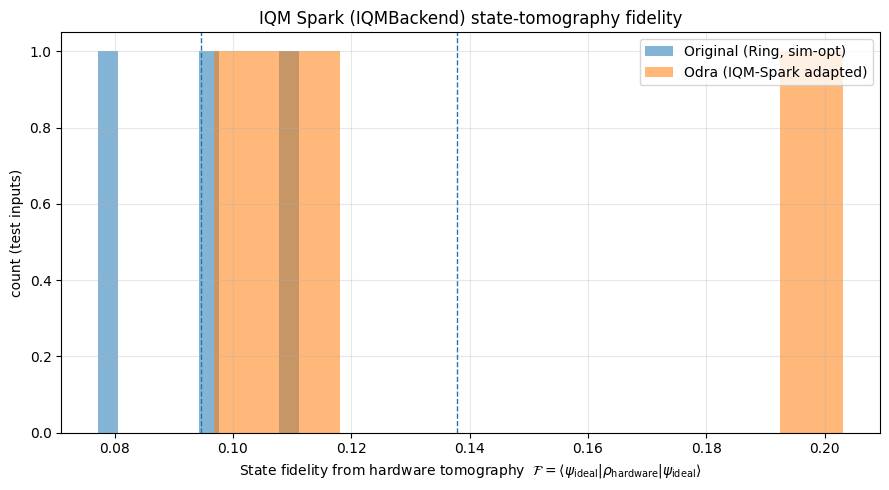

In [46]:
def summarise(blob: dict) -> dict:
    Fs_lin = np.array([r["fidelity_linear_inversion"]   for r in blob["per_input"]])
    Fs_phy = np.array([r["fidelity_physical_projection"] for r in blob["per_input"]])
    return {
        "n_inputs":      len(Fs_lin),
        "F_lin_mean":    float(Fs_lin.mean()),
        "F_lin_std":     float(Fs_lin.std(ddof=0)),
        "F_phys_mean":   float(Fs_phy.mean()),
        "F_phys_std":    float(Fs_phy.std(ddof=0)),
        "F_phys_min":    float(Fs_phy.min()),
        "F_phys_max":    float(Fs_phy.max()),
        "Fs_phys":       Fs_phy,
    }


print("=" * 90)
print(
    f"{'Ansatz':<32}{'n':>4}"
    f"{'F lin mean':>13}{'F lin std':>13}"
    f"{'F phys mean':>14}{'F phys std':>13}{'min':>9}{'max':>9}"
)
print("-" * 90)

summaries = {}
for label, blob in results.items():
    s = summarise(blob)
    summaries[label] = s
    print(
        f"{label:<32}{s['n_inputs']:>4}"
        f"{s['F_lin_mean']:>13.4f}{s['F_lin_std']:>13.4f}"
        f"{s['F_phys_mean']:>14.4f}{s['F_phys_std']:>13.4f}"
        f"{s['F_phys_min']:>9.4f}{s['F_phys_max']:>9.4f}"
    )
print("=" * 90)


fig, ax = plt.subplots(1, 1, figsize=(9, 5))
for label, s in summaries.items():
    ax.hist(s["Fs_phys"], bins=10, alpha=0.55, label=label)
    ax.axvline(s["F_phys_mean"], linestyle="--", linewidth=1)

ax.set_xlabel(
    r"State fidelity from hardware tomography  "
    r"$\mathcal{F} = \langle\psi_{\mathrm{ideal}}|\rho_{\mathrm{hardware}}|\psi_{\mathrm{ideal}}\rangle$"
)
ax.set_ylabel("count (test inputs)")
ax.set_title(f"IQM Spark ({iqm_backend.name}) state-tomography fidelity")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. IQM Spark Caveats

A few practical notes that affect how you read these numbers — same checklist as the screenshot:

- **Qubit order / bitstring endianness.** Qiskit returns bitstrings little-endian (rightmost char = qubit 0). `expectation_from_counts` already reverses the bitstring before zipping with the Pauli string, so this is handled, but worth double-checking if you ever switch backends.
- **Readout errors.** The tomography fidelity reported here **includes** IQM Spark's readout error (because that error is in the raw counts). If you want a pure "gate fidelity" number you'd need to apply readout error mitigation (calibration matrix, M3, IBU, …) to the counts before reconstructing $\rho$. We don't do that here; section 10 of `2_1_ansatz_comparison_error_gate.ipynb` already shows the live IQM Spark readout error rates per qubit if you want to estimate the readout-only contribution analytically.
- **Shot noise.** With `SHOTS_PER_BASIS = 2000` the per-$\langle P\rangle$ standard error is roughly $1/\sqrt{2000} \approx 0.022$. Linear inversion can therefore produce $\rho$ with slightly negative eigenvalues — that's why we report both the raw `F_lin` and the projected `F_phys` numbers.
- **Scaling.** Full tomography is $3^n$. For $n=5$ on IQM Spark this is feasible; at $n=10$ it would be 59049 circuits per input. Scale `N_TOMOGRAPHY_INPUTS` accordingly.

For a paper, this section gives the more physically correct estimate:

> *We estimate the output state fidelity by performing quantum state tomography on the IQM Spark measurement results. The experimental density matrix $\rho_{\mathrm{hardware}}$ is reconstructed from Pauli expectation values measured in all tensor-product X/Y/Z bases, and compared with the ideal simulated pure state $|\psi\rangle$ using $\mathcal{F} = \langle\psi|\rho|\psi\rangle$.*